In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.datasets import load_breast_cancer, make_moons
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams['figure.dpi'] = 90

## 1. A dataset that is NOT linearly separable

`make_moons` is a classic synthetic dataset: two classes that draw interlocking half-moons. **No straight line** can separate them correctly. No matter how we tune the weights, a linear boundary will misclassify points along the curve.

🔥 ACCURACY MÁXIMO ALCANZADO: 93.33% 🔥
Mejores parámetros encontrados: {'C': 0.1, 'gamma': 10}

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.96      0.88      0.92        26
           1       0.92      0.97      0.94        34

    accuracy                           0.93        60
   macro avg       0.94      0.93      0.93        60
weighted avg       0.93      0.93      0.93        60



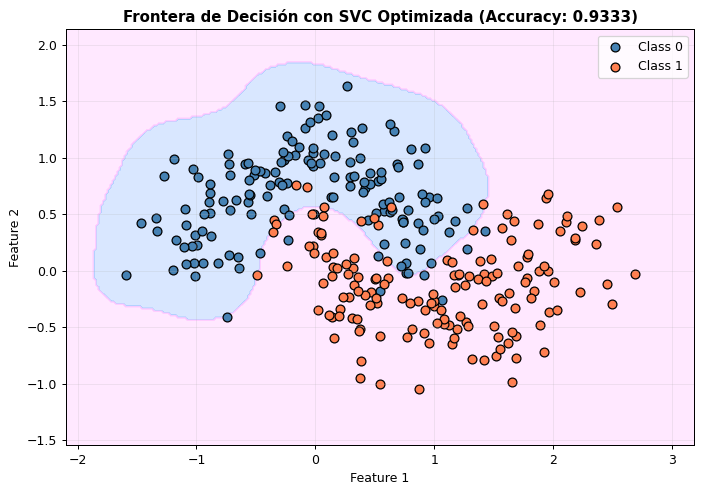

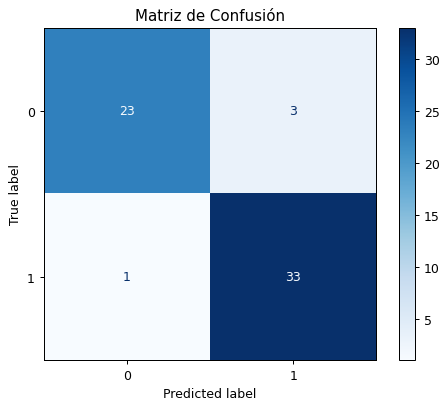

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

import warnings
warnings.filterwarnings('ignore')

# Configuración inicial
np.random.seed(42)
plt.rcParams['figure.dpi'] = 90

# 1. Generar y dividir los datos
X, y = make_moons(n_samples=300, noise=0.25, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Configurar el algoritmo (SVC con Kernel RBF) y la rejilla de parámetros
param_grid = {
    'C': [0.1, 1, 10, 100],       # Margen de regularización
    'gamma': [0.1, 1, 10, 'scale'] # Influencia de cada punto
}

# 3. Optimización con validación cruzada
grid_search = GridSearchCV(
    SVC(kernel='rbf', random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# 4. Entrenar el modelo
grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_

# 5. Predicción y Evaluación
y_pred = best_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print("=" * 55)
print(f"🔥 ACCURACY MÁXIMO ALCANZADO: {acc * 100:.2f}% 🔥")
print(f"Mejores parámetros encontrados: {grid_search.best_params_}")
print("=" * 55)
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred))

# ==========================================
# 6. VISUALIZACIÓN DE LA FRONTERA DE DECISIÓN
# ==========================================
plt.figure(figsize=(9, 6))

# Crear una malla que cubra todo el gráfico
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Predecir cada punto de la malla para pintar el fondo
Z = best_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Colores del fondo y dibujo de contornos
cmap_light = ListedColormap(['#a0c4ff', '#ffc6ff'])
plt.contourf(xx, yy, Z, alpha=0.4, cmap=cmap_light)

# Pintar los puntos de datos reales
plt.scatter(X[y==0, 0], X[y==0, 1], c='steelblue', label='Class 0', edgecolor='k', s=50)
plt.scatter(X[y==1, 0], X[y==1, 1], c='coral', label='Class 1', edgecolor='k', s=50)

plt.title(f'Frontera de Decisión con SVC Optimizada (Accuracy: {acc:.4f})', fontweight='bold')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(alpha=0.2)
plt.show()

# 7. Matriz de Confusión
ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test, cmap='Blues')
plt.title('Matriz de Confusión')
plt.show()

Mejores hiperparámetros: {'C': 0.1, 'gamma': 10}
SVC RBF accuracy (test): 0.933


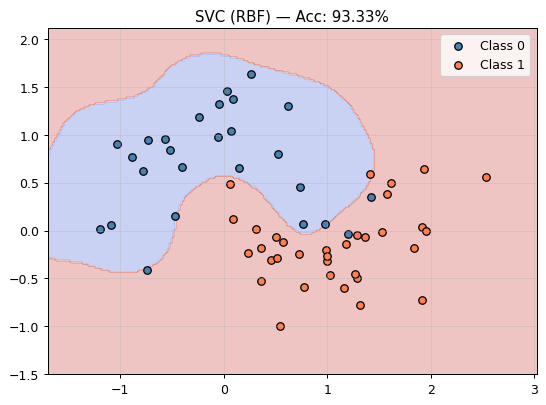

In [3]:
def plot_decision_boundary(model, X, y, title):
    """Visualize the model's decision boundary on the 2D plane."""
    h = 0.02
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    
    plt.figure(figsize=(7, 5))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    plt.scatter(X[y==0, 0], X[y==0, 1], c='steelblue', edgecolor='k', label='Class 0')
    plt.scatter(X[y==1, 0], X[y==1, 1], c='coral', edgecolor='k', label='Class 1')
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

# 1. Búsqueda de los mejores hiperparámetros para SVC
param_grid = {'C': [0.1, 1, 10, 100], 'gamma': [0.1, 1, 10, 'scale']}
grid_search = GridSearchCV(SVC(kernel='rbf', random_state=42), param_grid, cv=5)
grid_search.fit(X_train, y_train)

# 2. Extraer el mejor modelo
best_svc = grid_search.best_estimator_

# 3. Predecir y calcular accuracy
acc_svc = accuracy_score(y_test, best_svc.predict(X_test))
print(f'Mejores hiperparámetros: {grid_search.best_params_}')
print(f'SVC RBF accuracy (test): {acc_svc:.3f}')

# 4. Graficar usando tu función
plot_decision_boundary(best_svc, X_test, y_test, f'SVC (RBF) — Acc: {acc_svc:.2%}')

Logistic regression (Polynomial) accuracy (test): 0.933


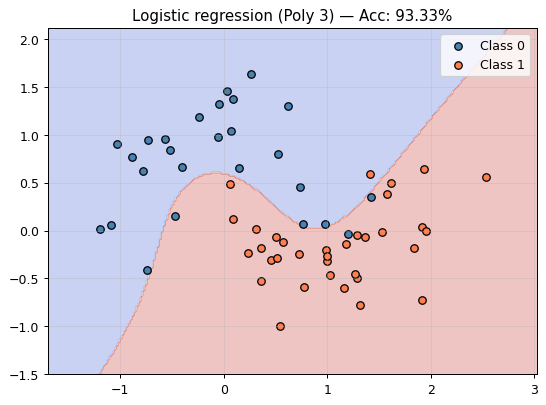

In [4]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

def plot_decision_boundary(model, X, y, title):
    """Visualize the model's decision boundary on the 2D plane."""
    h = 0.02
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    plt.figure(figsize=(7, 5))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    plt.scatter(X[y==0, 0], X[y==0, 1], c='steelblue', edgecolor='k', label='Class 0')
    plt.scatter(X[y==1, 0], X[y==1, 1], c='coral', edgecolor='k', label='Class 1')
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

# Transformamos los datos a grado 3 y aplicamos la Regresión Logística en un solo paso
logreg = make_pipeline(
    PolynomialFeatures(degree=3, include_bias=False), 
    LogisticRegression(C=10, random_state=42)
)

logreg.fit(X_train, y_train)
acc_logreg = accuracy_score(y_test, logreg.predict(X_test))

print(f'Logistic regression (Polynomial) accuracy (test): {acc_logreg:.3f}')
plot_decision_boundary(logreg, X_test, y_test, f'Logistic regression (Poly 3) — Acc: {acc_logreg:.2%}')

Decision Tree accuracy (test): 0.900


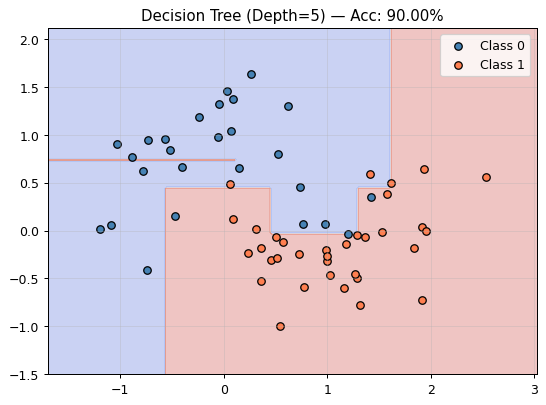

In [5]:
# 1. Entrenar el Árbol de Decisión
tree_model = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_model.fit(X_train, y_train)

# 2. Calcular el accuracy en el set de prueba
acc_tree = accuracy_score(y_test, tree_model.predict(X_test))
print(f'Decision Tree accuracy (test): {acc_tree:.3f}')

# 3. Graficar la frontera ortogonal (en forma de escalera)
plot_decision_boundary(tree_model, X_test, y_test, f'Decision Tree (Depth=5) — Acc: {acc_tree:.2%}')

Decision tree accuracy (max_depth=5, test): 0.900
Improvement over logistic regression: +-3.3 points


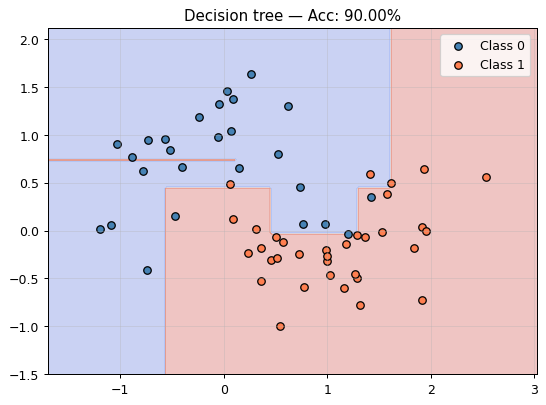

In [6]:
tree = DecisionTreeClassifier(max_depth=5, random_state=42)
tree.fit(X_train, y_train)
acc_tree = accuracy_score(y_test, tree.predict(X_test))

print(f'Decision tree accuracy (max_depth=5, test): {acc_tree:.3f}')
print(f'Improvement over logistic regression: +{(acc_tree - acc_logreg)*100:.1f} points')

plot_decision_boundary(tree, X_test, y_test, f'Decision tree — Acc: {acc_tree:.2%}')